<br>
    Visualization of ICON and eCLM 2d fields<br>
<br>    
    Author: Stefan POLL   <br>
    reference:  DKRZ_example_ICON_triangles.py from kmf<br>


Import Libs

In [1]:
import time, os
import xarray as xr
import numpy as np
import numpy.ma as ma
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from   matplotlib.collections import PolyCollection
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import getpass

%matplotlib inline

Start program

In [2]:
def main():
    t1 = time.time()    #-- retrieve start time

In [3]:
    #-- set title string
    title = ' '

In [14]:
    username=getpass.getuser()
    model='icon'#'eclm'
    varName   = 'theta_v' #'TG'
    itsp      = 12 # timestep 
    fnameout  = 'plot_'+varName+'_'+model+'_201707_latbc.pdf'
    
    
    dir_name = '/p/project1/training2538/'+username+'/simexp_real_CORDEX-EUR-11u_icon-eclm-parflow//dta/simres/iconeclmparflow_20170701/out/'+model+'/'
    dirgrid_name = '/p/project1/training2538/'+username+'/simexp_real_CORDEX-EUR-11u_icon-eclm-parflow/dta/geo/'+model+'/static/'
    if (model=='eclm'):
        grid_name = 'domain.lnd.ICON-11_ICON-11.230302_landlake_halo.nc'
        file_name = 'eCLM_eur-11u.clm2.h0.2017-07-01-00000.nc'
    else:
        grid_name = 'europe011_DOM01.nc'
        file_name = 'ICON_out_EU-R13B5_inst_DOM01_ML_20170701T000000Z_1h.nc' 

In [15]:
    fname = os.path.join(dir_name,file_name)
    gname = os.path.join(dirgrid_name,grid_name)
    if (model=='eclm'):
        file_mask = dirgrid_name+'../../eclm/static/domain.lnd.ICON-11_ICON-11.230302_landlake_halo.nc'
        varsel = ['mask']
        dsm    = xr.open_dataset(file_mask)[varsel]
        mask   = dsm["mask"].values
    else:
        file_mask = dirgrid_name+'/external_parameter_icon_europe011_DOM01_tiles.nc'
        varsel = ['FR_LAND']
        dsm    = xr.open_dataset(file_mask)[varsel]
        mask   = dsm["FR_LAND"].values

In [16]:
    fname = os.path.join(dir_name,file_name)
    gname = os.path.join(dirgrid_name,grid_name)

In [17]:
    varsel = [varName] 
    ds     = xr.open_dataset(fname)[varsel]

/p/project1/training2538/poll1/simexp_real_CORDEX-EUR-11u_icon-eclm-parflow//dta/simres/iconeclmparflow_20170701/out/icon/ICON_out_EU-R13B5_inst_DOM01_ML_20170701T000000Z_1h.nc


In [18]:
    if (model=='eclm'):
        varsel = ['xc','yc','xv','yv']
    else:
        varsel = ['clon','clat','clon_vertices','clat_vertices']
    dsgrid = xr.open_dataset(gname)[varsel]

In [21]:
    #-- get variable
#    var = ds[varName][itsp,:].values
    var = ds[varName][itsp,59,:].values
#    var = ds[varName].values

#    var = (var/max(var))
#    var = var*1e-6
    print(var.shape)

(199920,)


In [23]:
    #-- get coordinates and convert radians to degrees
    if (model=='eclm'):
        clon = np.squeeze(dsgrid.xc.values)
        clat = np.squeeze(dsgrid.yc.values)
        clon_vertices = np.squeeze(dsgrid.xv.values)
        clat_vertices = np.squeeze(dsgrid.yv.values)
    else:
        clon = np.rad2deg(dsgrid.clon.values)
        clat = np.rad2deg(dsgrid.clat.values)
        clon_vertices = np.rad2deg(dsgrid.clon_vertices.values)
        clat_vertices = np.rad2deg(dsgrid.clat_vertices.values)
    ncells, nv = clon_vertices.shape[0], clon_vertices.shape[1]    
    
    #-- set contour levels, labels
#    varMin, varMax, varInt = 0.65, 1., 0.01
#    varMin, varMax, varInt = min(var), max(var), (max(var)-min(var))/5
    varMin, varMax, varInt = 255., 330., (330-255)/15
    levels = np.arange(varMin, varMax+varInt, varInt)
    nlevs  = levels.size
    labels = ['{:.2f}'.format(x) for x in levels]

    #-- print information to stdout
    print('')
    print('Cells:            %6d ' % clon.size)
    print('Variable min/max: %6.2f ' % np.nanmin(var)+'/'+' %.2f' % np.nanmax(var))
    print('Contour  min/max: %6.2f ' % varMin+'/'+' %.2f' % varMax)
    print('')

    #-- set projection
    projection = ccrs.PlateCarree()



Cells:            199920 
Variable min/max: 272.45 / 324.70
Contour  min/max: 255.00 / 330.00



In [28]:

    #-- define color map
    cmap     = plt.get_cmap('Spectral_r', nlevs)        #-- read the color map
#    cmap     = plt.get_cmap('viridis_r', nlevs)        #-- read the color map
#    cmap     = plt.get_cmap('bwr', nlevs)        #-- read the color map
#    cmap     = plt.get_cmap('summer', nlevs) 
    cmaplist = [i for i in range(cmap.N)]               #-- color bar indices
    ncol     = len(cmaplist)                            #-- number of colors
    colors   = np.ndarray([ncells,4], np.float32)       #-- assign color array for triangles
    print('levels:      ',levels)
    print('nlevs:       %3d' %nlevs)
    print('ncol:        %3d' %ncol)
    print('')
    
    #-- set color index of all cells in between levels
    for m in range(0,ncol-1):
        vind = []
        for i in range(0,ncells-2, 1):
            if (var[i] >= levels[m] and var[i] < levels[m+1]):
               colors[i,:] = cmap(cmaplist[m])
               vind.append(i)
        print('set colors: finished level %3d' % m ,
              ' -- %5d ' % len(vind) ,
              ' polygons considered')
        del vind
    colors[np.where(var < varMin),:]  = cmap(cmaplist[0])
    colors[np.where(var >= varMax),:] = cmap(cmaplist[ncol-1])
    colors[np.where(mask < 0.5),:] = [0.5,0.5,0.5,1]

    #-- create the triangles
    clon_vertices = np.where(clon_vertices < -180., clon_vertices + 360., clon_vertices)
    clon_vertices = np.where(clon_vertices >  180., clon_vertices - 360., clon_vertices)
    triangles = np.zeros((ncells, nv, 2), np.float32)
    for i in range(0, ncells, 1):
        triangles[i,:,0] = np.array(clon_vertices[i,:])
        triangles[i,:,1] = np.array(clat_vertices[i,:])
    print('')
    print('--> triangles done')
    colors = np.where(colors>1, 1, colors) # SPo dirty debug

levels:       [255. 260. 265. 270. 275. 280. 285. 290. 295. 300. 305. 310. 315. 320.
 325. 330.]
nlevs:        16
ncol:         16

set colors: finished level   0  --     0   polygons considered
set colors: finished level   1  --     0   polygons considered
set colors: finished level   2  --     0   polygons considered
set colors: finished level   3  --   965   polygons considered
set colors: finished level   4  --  9013   polygons considered
set colors: finished level   5  -- 25140   polygons considered
set colors: finished level   6  -- 34834   polygons considered
set colors: finished level   7  -- 30380   polygons considered
set colors: finished level   8  -- 26159   polygons considered
set colors: finished level   9  -- 18022   polygons considered
set colors: finished level  10  -- 15868   polygons considered
set colors: finished level  11  -- 16507   polygons considered
set colors: finished level  12  -- 11832   polygons considered
set colors: finished level  13  --  1254   polygo

--> polygon collection done


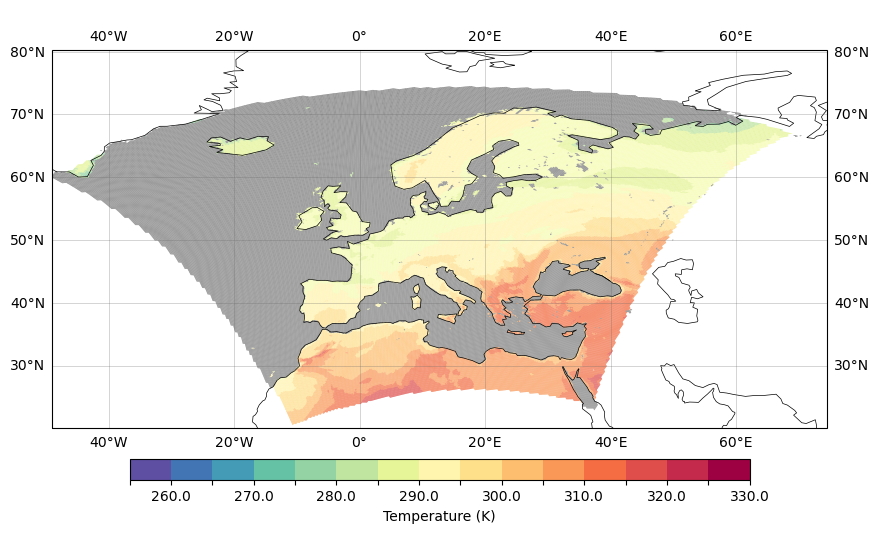

In [29]:
    #-- create figure and axes instances; we need subplots for plot and colorbar
    fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(projection=projection))
    ax.set_global()
  
    ax.set_extent([-49, 74.5, 20, 70.])

    #-- plot land areas at last to get rid of the contour lines at land
    ax.coastlines(linewidth=0.5, zorder=2)
    ax.gridlines(draw_labels=True, linewidth=0.5, color='dimgray', alpha=0.4,
                 zorder=2)

    #-- plot the title string
    plt.title(title)
    #-- create polygon/triangle collection
    coll = PolyCollection(triangles, array=None, fc=colors, edgecolors='black',
                          linewidth=0.00, transform=ccrs.Geodetic(), zorder=0)
    ax.add_collection(coll)
    print('--> polygon collection done')

    #-- add a color bar
    cb = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=varMin, vmax=varMax))
    cb.set_array([])
    cbar = plt.colorbar(cb,
                        orientation='horizontal',
                        ticks=levels,
                        boundaries=levels,
                        format='%0.1f',
                        shrink=0.8,
                        pad=0.04,
                        aspect=30,
                        )
    plt.setp(cbar.ax.get_xticklabels()[::2], visible=False)
    cbar.set_label('Temperature (K)')

    #-- maximize and save the PNG file
#    plt.savefig('plot_ICON_output_triangles.pdf', bbox_inches='tight')
    plt.savefig(fnameout, bbox_inches='tight')



In [ ]:
    #-- get wallclock time
    t2 = time.time()
    print('Wallclock time:  %0.3f seconds' % (t2-t1))
    print('')